# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "chcl3"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69]] [[6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819]] [[6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555]] ... [[6.316 6.316 6.316 ... 13.918333333333333 13.123166666666668 12.328] [6.316 6.316 6.316 ... 13.918333333333333 13.123166666666666 12.328] [6.316 6.316 6.316 ... 12.4035 13.123166666666666 12.328] [6.316 6.316 6.316 ... 12.399333333333333 12.363666666666667 12.328] [6.316 6.316 6.316 ... 13.158833333333332 13.123166666666666 12.328] [6.316 6.316 6.316 ... 13.918333333333333 13.123166666666666 12.328]] [[5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.468 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.611 13.254000000000001 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.772166666666667 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666668 12.897]] [[5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333335 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333333 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.566 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.006 13.0175 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.274666666666667 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333331 13.286166666666666 13.029]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69] [6.654 6.654 6.654 ... 11.69 11.69 11.69]] [[6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819] [6.599 6.599 6.599 ... 12.819 12.819 12.819]] [[6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555] [6.657 6.657 6.657 ... 12.555 12.555 12.555]] ... [[6.316 6.316 6.316 ... 13.918333333333333 13.123166666666668 12.328] [6.316 6.316 6.316 ... 13.918333333333333 13.123166666666666 12.328] [6.316 6.316 6.316 ... 12.4035 13.123166666666666 12.328] [6.316 6.316 6.316 ... 12.399333333333333 12.363666666666667 12.328] [6.316 6.316 6.316 ... 13.158833333333332 13.123166666666666 12.328] [6.316 6.316 6.316 ... 13.918333333333333 13.123166666666666 12.328]] [[5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.468 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.611 13.254000000000001 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.772166666666667 13.415166666666666 12.897] [5.7524999999999995 5.7524999999999995 5.7524999999999995 ... 13.933333333333334 13.415166666666668 12.897]] [[5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333335 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333333 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.566 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.006 13.0175 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.274666666666667 13.286166666666666 13.029] [5.2330000000000005 5.2330000000000005 5.2330000000000005 ... 13.543333333333331 13.286166666666666 13.029]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'chcl3' (lon: 6, lat: 12, year: 27, month: 12)> Size: 187kB
<Quantity([[[[ 5.088       4.851       4.837      ...  6.387       5.98
     5.571     ]
   [ 5.192       5.1575      5.054      ...  6.906       6.496
     5.937     ]
   [ 5.436       5.176       5.15       ...  6.557       6.425
     5.6375    ]
   ...
   [ 4.8835      4.7965      4.868      ...  6.471       6.079
     5.4605    ]
   [ 5.554       4.9355      4.9925     ...  6.2345      5.664
     5.3345    ]
   [ 4.877       4.684       4.594      ...  6.316       5.7525
     5.233     ]]

  [[ 5.088       4.851       4.837      ...  6.387       5.98
     5.571     ]
   [ 5.192       5.1575      5.054      ...  6.906       6.496
     5.937     ]
   [ 5.436       5.176       5.15       ...  6.557       6.425
     5.6375    ]
...
   [13.508      13.46116667 13.46933333 ... 13.226      14.02083333
    13.96766667]
   [13.65416667 13.47733333 12.942      ... 13.02683333 13.08533333
    12.7695    ]
   [12.33516667 12.40333333 12.227      ... 13.12316667 13.41516667
    13.28616667]]

  [[13.88       12.181      12.175      ... 11.914      12.723
    12.637     ]
   [12.664      12.208      11.853      ... 12.255      12.413
    12.252     ]
   [12.1255     11.823      11.7595     ... 12.8325     12.7205
    12.78      ]
   ...
   [12.82       13.008      13.135      ... 12.695      13.91
    14.002     ]
   [13.682      13.282      12.745      ... 12.956      12.716
    12.489     ]
   [12.071      12.062      11.974      ... 12.328      12.897
    13.029     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 216B 1997 1998 1999 2000 2001 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 13.918333333333333 13.933333333333334 13.543333333333335] [13.88 12.181 12.175 ... 13.123166666666668 13.415166666666666 13.286166666666666] [13.88 12.181 12.175 ... 12.328 12.897 13.029]] [[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 13.918333333333333 13.933333333333334 13.543333333333333] [13.88 12.181 12.175 ... 13.123166666666666 13.415166666666666 13.286166666666666] [13.88 12.181 12.175 ... 12.328 12.897 13.029]] [[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 12.4035 13.468 13.566] [13.88 12.181 12.175 ... 13.123166666666666 13.415166666666666 13.286166666666666] [13.88 12.181 12.175 ... 12.328 12.897 13.029]] [[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 12.399333333333333 13.611 13.006] [13.88 12.181 12.175 ... 12.363666666666667 13.254000000000001 13.0175] [13.88 12.181 12.175 ... 12.328 12.897 13.029]] [[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 13.158833333333332 13.772166666666667 13.274666666666667] [13.88 12.181 12.175 ... 13.123166666666666 13.415166666666666 13.286166666666666] [13.88 12.181 12.175 ... 12.328 12.897 13.029]] [[5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] [5.088 4.851 4.837 ... 6.316 5.7524999999999995 5.2330000000000005] ... [13.88 12.181 12.175 ... 13.918333333333333 13.933333333333334 13.543333333333331] [13.88 12.181 12.175 ... 13.123166666666666 13.415166666666668 13.286166666666666] [13.88 12.181 12.175 ... 12.328 12.897 13.029]]]
Units,ppt


### Longitudinal-mean

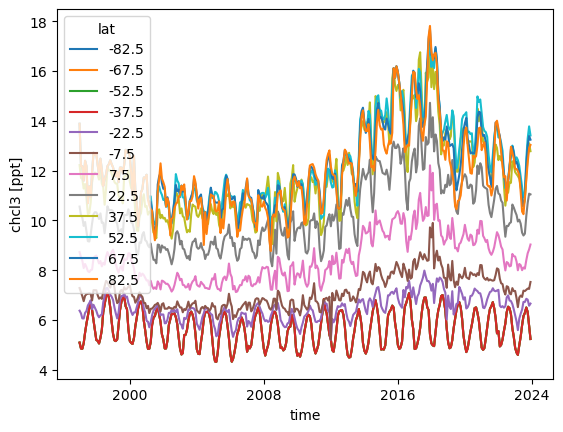

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

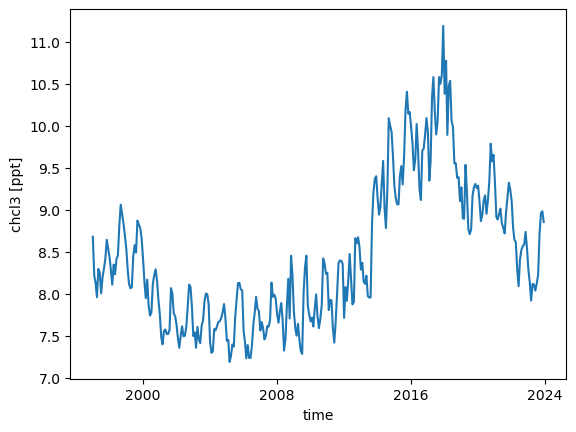

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

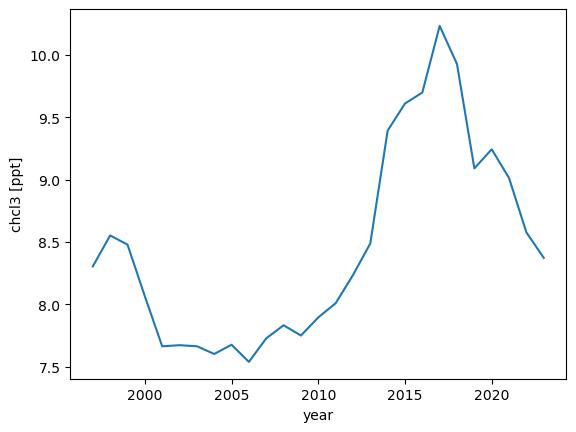

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 27)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 216B 1997 1998 1999 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.2941 ... 0.0001292
    principal-components  (year, eof) float64 3kB [] -9.242 ... -6.787e-18

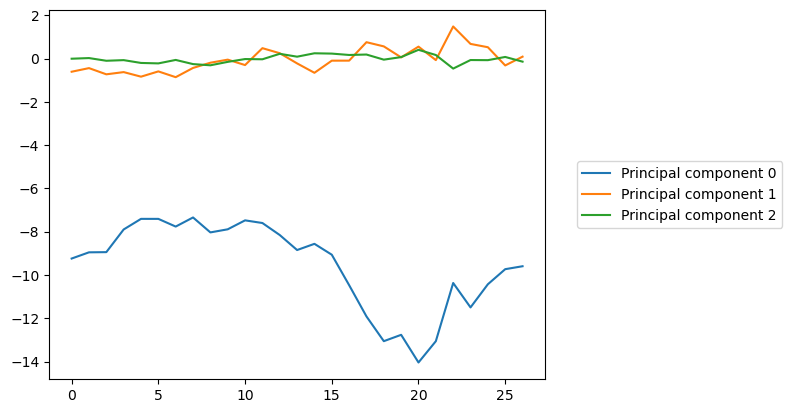

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

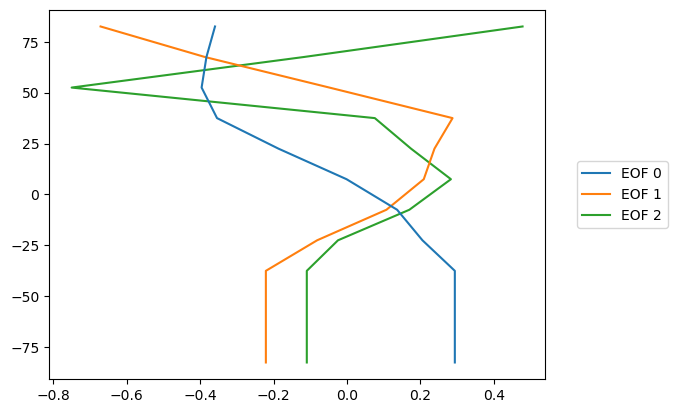

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

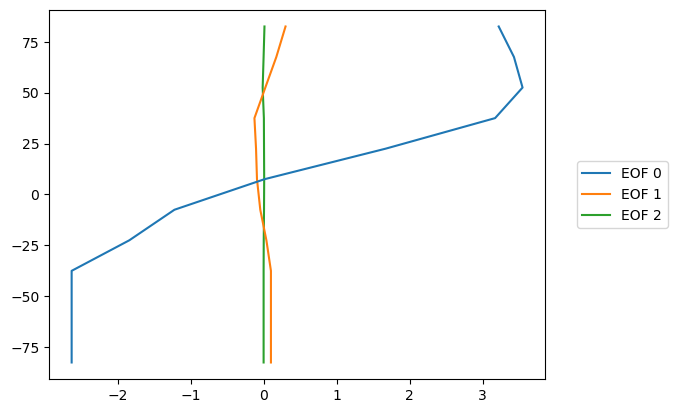

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.29407058504814776] [0.2940705850481476] [0.2940705850481478] [0.2940705850481478] [0.20581191972359528] [0.13674496274086828] [-0.0010713213888972576] [-0.18657484522814416] [-0.35408136838363524] [-0.3960978067939659] [-0.3829554867055693] [-0.3595815895171853]]
Units,ppt
Magnitude,[[-9.242159059090984] [-8.954994158369292] [-8.946268944739314] [-7.898512386529297] [-7.409161744162359] [-7.409653129755528] [-7.764877174720808] [-7.344288390070446] [-8.03454763520098] [-7.891074507554817] [-7.4778644106176815] [-7.60078245652101] [-8.155756764846513] [-8.848989348038957] [-8.562448673826838] [-9.064985138362712] [-10.47084647766063] [-11.91638677680871] [-13.059619931409186] [-12.766277758041094] [-14.044007030808373] [-13.06074840132705] [-10.372181263478527] [-11.499901396568895] [-10.43033812942622] [-9.73357101699091] [-9.597546578875049]]
Units,dimensionless


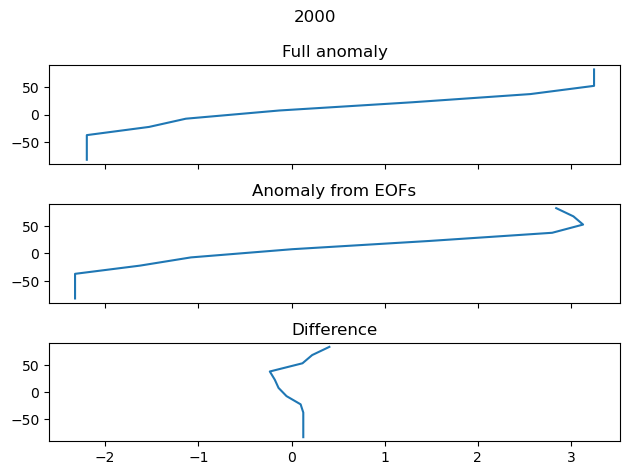

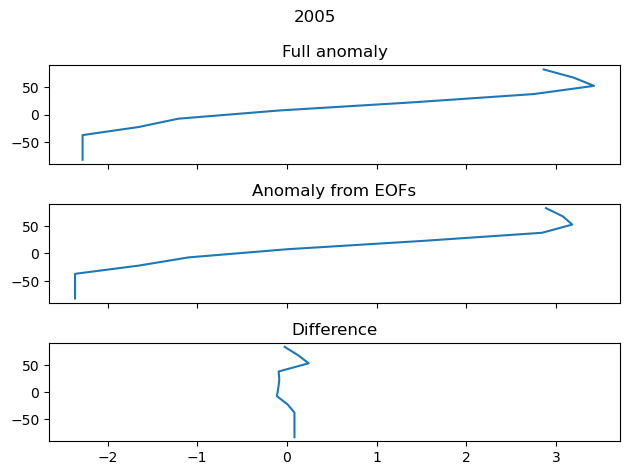

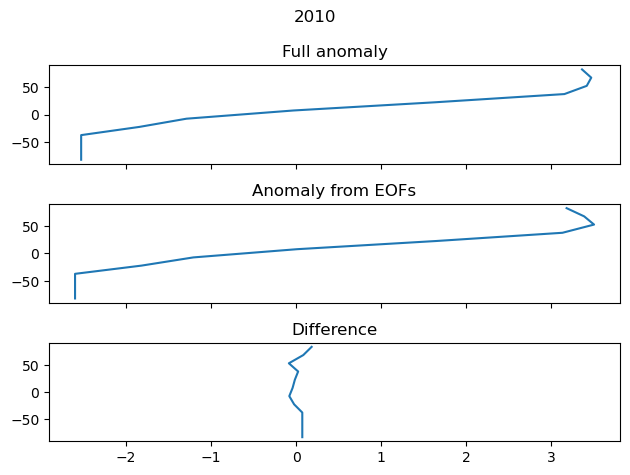

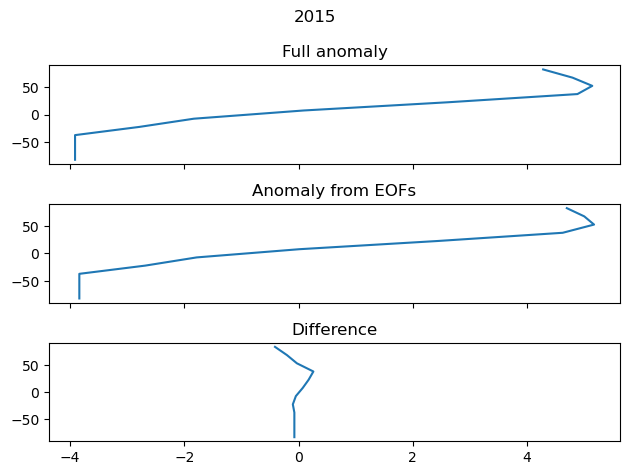

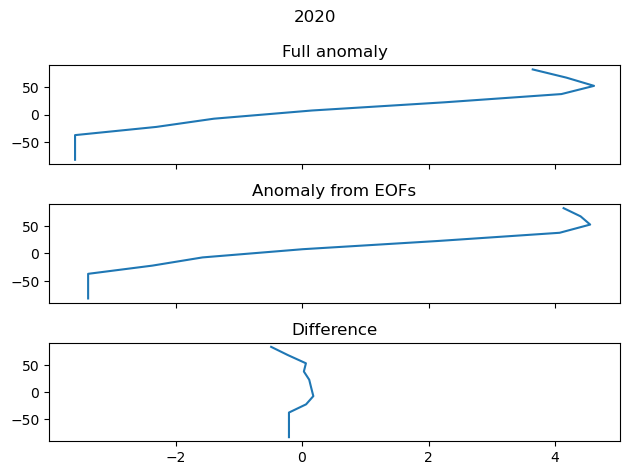

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/324 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:00<00:00, 18253.50it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/324 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/324 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:00<00:00, 20003.45it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/324 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 324/324 [00:00<00:00, 20091.88it/s]

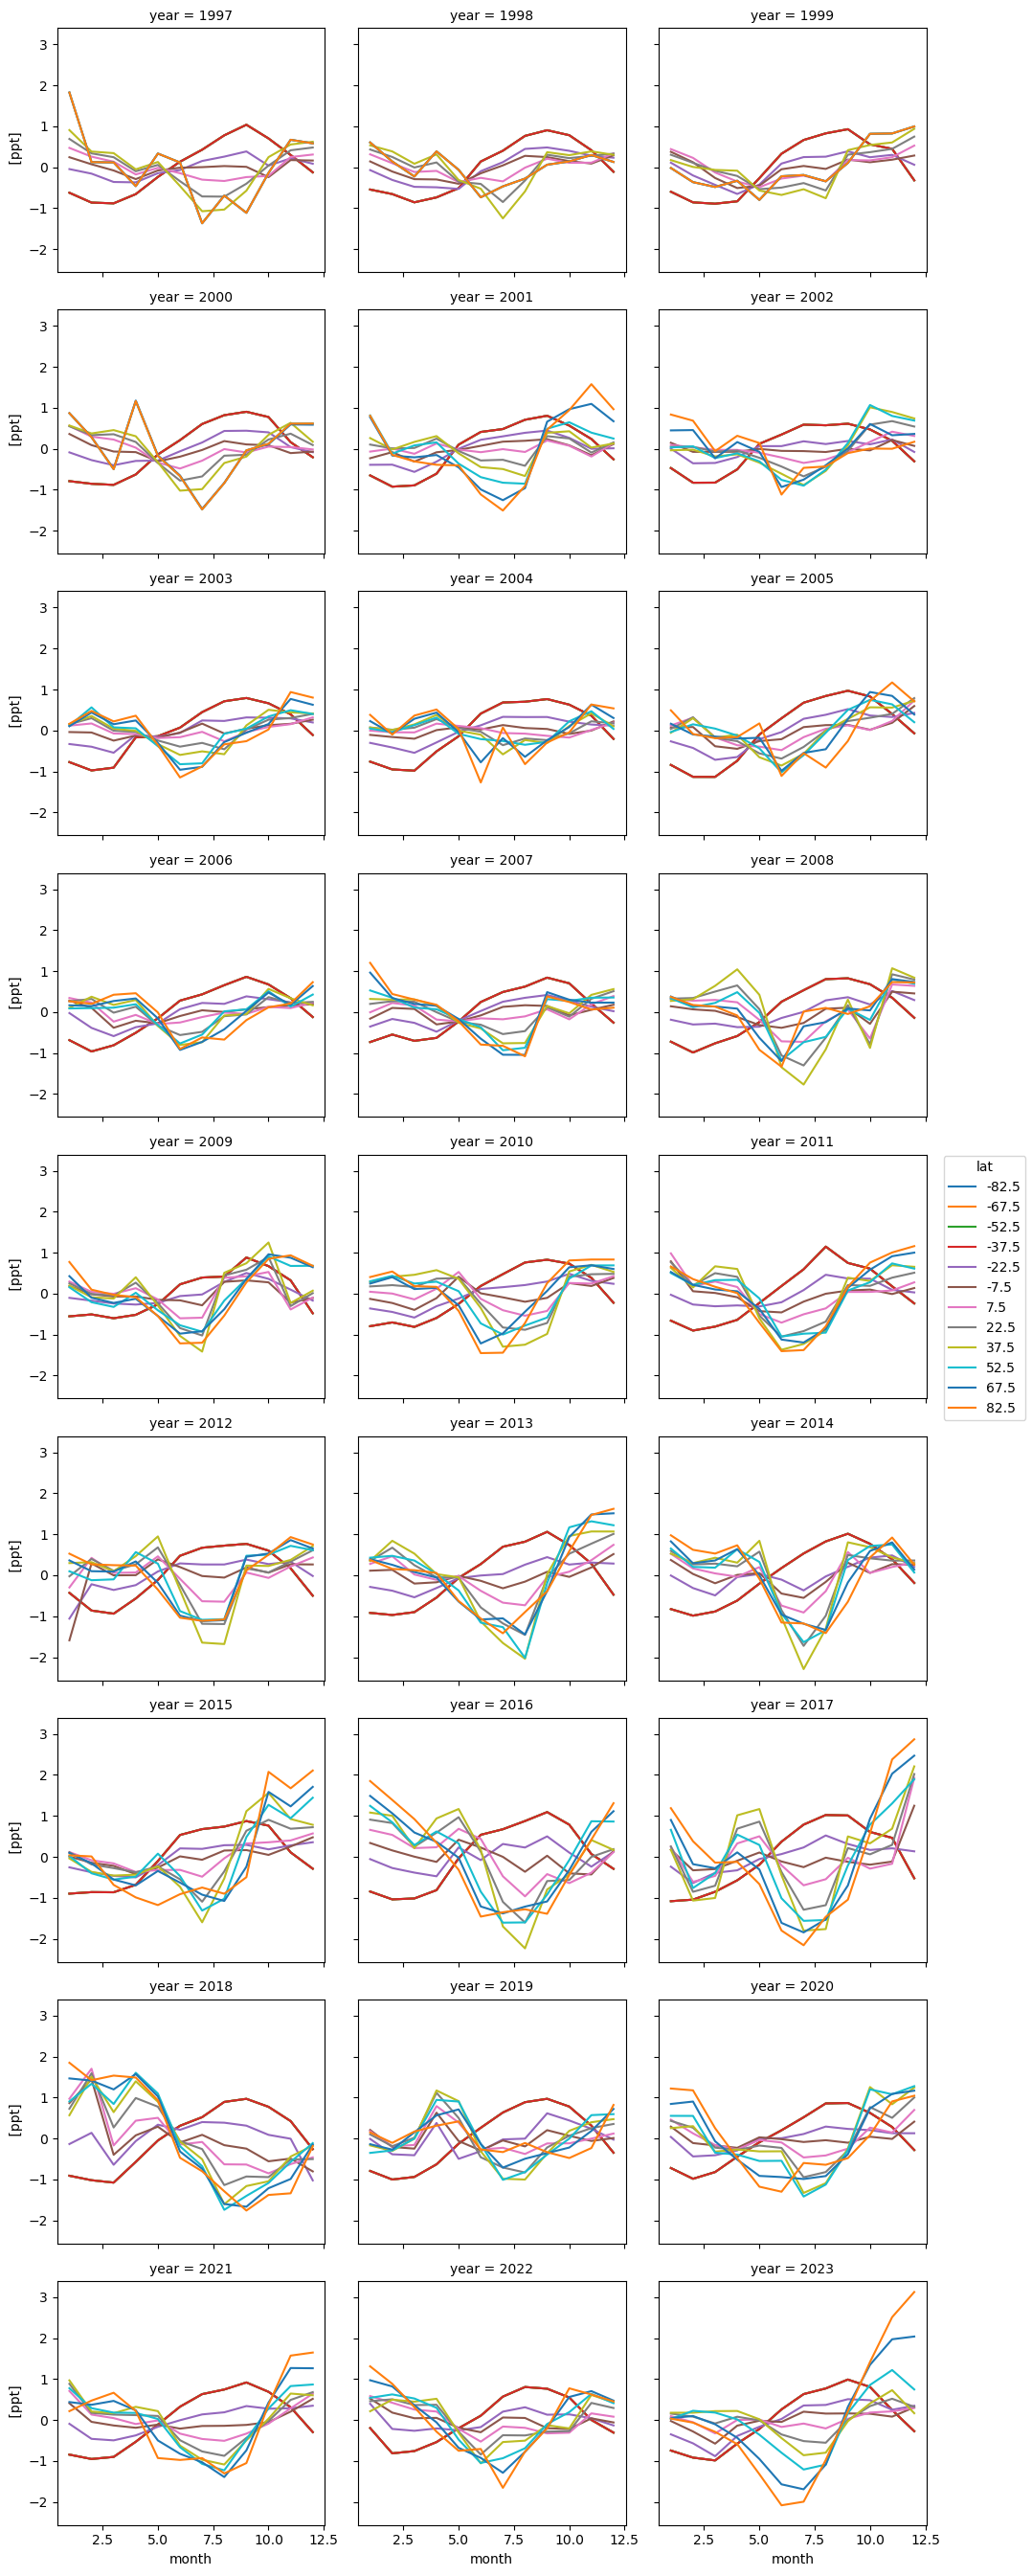

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

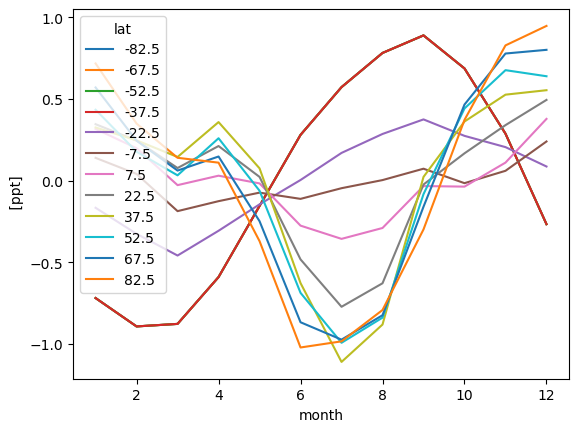

In [22]:
seasonality.plot.line(hue="lat")

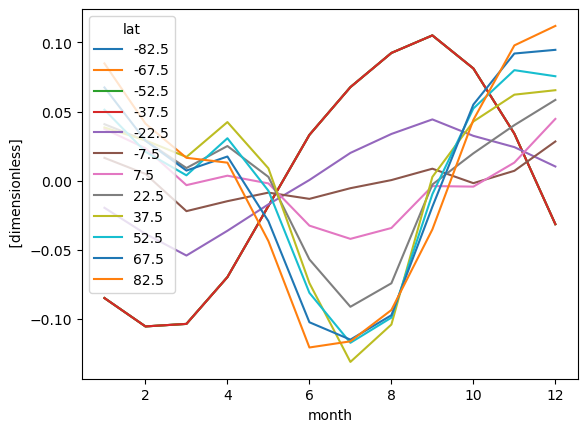

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[8.305576642852065 8.55306983493008 8.479700895465394 8.06552904640796 7.664565806468997 7.673319819119903 7.665040572934498 7.6030562607249434 7.6770898680421675 7.539345153382434 7.728352245547371 7.83324148371734 7.750891792032423 7.896037333825139 8.009539173203136 8.235104909152506 8.48918934757935 9.39330865663966 9.610720049397536 9.698838571700497 10.232760202962938 9.926109412361447 9.090645660072878 9.243766519655933 9.01342391406513 8.577662201928625 8.37393357145224]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.29407058504814776] [0.2940705850481476] [0.2940705850481478] [0.2940705850481478] [0.20581191972359528] [0.13674496274086828] [-0.0010713213888972576] [-0.18657484522814416] [-0.35408136838363524] [-0.3960978067939659] [-0.3829554867055693] [-0.3595815895171853]]
Units,ppt
Magnitude,[[-9.242159059090984] [-8.954994158369292] [-8.946268944739314] [-7.898512386529297] [-7.409161744162359] [-7.409653129755528] [-7.764877174720808] [-7.344288390070446] [-8.03454763520098] [-7.891074507554817] [-7.4778644106176815] [-7.60078245652101] [-8.155756764846513] [-8.848989348038957] [-8.562448673826838] [-9.064985138362712] [-10.47084647766063] [-11.91638677680871] [-13.059619931409186] [-12.766277758041094] [-14.044007030808373] [-13.06074840132705] [-10.372181263478527] [-11.499901396568895] [-10.43033812942622] [-9.73357101699091] [-9.597546578875049]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.08495445112307524 -0.10548143494596898 -0.10365454626418695 -0.06977075387979476 -0.0182965670412322 0.03314069778766317 0.0676892970061276 0.09243287272979868 0.1051418170783444 0.08121585985640915 0.03401452951905337 -0.03147731723737139] [-0.08495445112307524 -0.10548143494596898 -0.10365454626418695 -0.06977075387979476 -0.0182965670412322 0.03314069778766317 0.0676892970061276 0.09243287272979868 0.1051418170783444 0.08121585985640915 0.03401452951905337 -0.03147731723737139] [-0.08495445112307524 -0.10548143494596898 -0.10365454626418695 -0.06977075387979476 -0.0182965670412322 0.03314069778766317 0.0676892970061276 0.09243287272979868 0.1051418170783444 0.08121585985640915 0.03401452951905337 -0.03147731723737139] [-0.08495445112307524 -0.10548143494596898 -0.10365454626418695 -0.06977075387979476 -0.0182965670412322 0.03314069778766317 0.0676892970061276 0.09243287272979868 0.1051418170783444 0.08121585985640915 0.03401452951905337 -0.03147731723737139] [-0.019626902239232323 -0.03847292102651016 -0.0541812982823374 -0.036257955318957605 -0.017138222899943947 0.00048072854549821857 0.02008769313192531 0.03380031135662303 0.04433645284095437 0.03242944035956364 0.024283399746727143 0.01025928298823275] [0.016504006325000774 0.004871605350273273 -0.022050717586496012 -0.014834712826666265 -0.008654655519972387 -0.013169678965996875 -0.005449091015485481 0.000425371472204124 0.00866163524112882 -0.0018038461149406872 0.0071385085471962545 0.028361554999358513] [0.03744063718768239 0.023491824457568825 -0.0032316914888486565 0.0036056646043016267 -0.00197858839420778 -0.032537168327748216 -0.042116753244480276 -0.03424701635197909 -0.0039050075785400495 -0.004305079228973219 0.0130784642175795 0.044704665009498226] [0.040883466946965936 0.029006233323566406 0.00915175170768653 0.025070743852567117 0.0027306173594746222 -0.05697861671124528 -0.09126724614206838 -0.07425757332897531 -0.0027696376140110127 0.019792955070384394 0.040195294662171255 0.05844193535581828] [0.03849044875441389 0.029193160809839774 0.01714257747923145 0.042398032652865715 0.008926063233989024 -0.07411655259789109 -0.1311750994099197 -0.10412120980602245 0.0027284946412749022 0.042813927420487945 0.06224559058217114 0.0654744553881155] [0.0513449017331237 0.020963832534020684 0.0038655312504689526 0.03070079337214526 -0.0072930701756224615 -0.081182626102324 -0.11732329192489836 -0.09912961524496436 -0.009756352356119052 0.05225927982476103 0.07997565085981036 0.07557491643669352] [0.06746371744467383 0.02899414534000714 0.007305738264308954 0.017482854934026276 -0.029318134054257837 -0.1024670711005535 -0.11504737616510213 -0.09737593352887977 -0.018842406275201062 0.05509612626011026 0.09201849165045063 0.09468995014041758] [0.08483957045271036 0.041323864098166255 0.016550443928285558 0.013038156160232909 -0.04374871645422428 -0.12072370393230893 -0.11628374552852952 -0.0936034455178617 -0.03527287852378222 0.04399018257854207 0.09789558830999869 0.11199491300676612]]
Units,dimensionless
